# **ELECTRIC VEHICLE POPULATION DATA**

## **Introduction**

This project analyzes the Electric Vehicle Population Data obtained from the Washington State Open Data Portal. The dataset contains information on Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs) registered through the Washington State Department of Licensing (DOL).

The purpose of this project is to explore electric vehicle adoption trends, regional distribution patterns, and key factors that influence the growth of electric vehicles across Washington State. Through data preprocessing and exploratory data analysis, this study aims to extract meaningful insights that can support transportation planning, environmental policy, and sustainable mobility initiatives.

## **Dataset Information**

* Source URL: https://catalog.data.gov/dataset/electric-vehicle-population-data
* Data Type: CSV (Comma Separated Values)
* Number of Rows: 269673
* Number of Columns: 16


## **Attribute Information**

* VIN (1–10)
* County
* City
* State
* Postal Code
* Model Year
* Make
* Model
* Electric Vehicle Type
* Clean Alternative Fuel Vehicle (CAFV) Eligibility
* Electric Range
* Legislative District
* DOL Vehicle ID
* Vehicle Location
* Electric Utility
* 2020 Census Tract

### **Steps**

1. Data Loading and Initial Overview
2. Data Pre-processing
3. Exploratory Data Analysis (EDA)
4. Visualizations and report generation

### **Step 1: Data Loading and Initial Overview**

In this step, we load the Electric Vehicle Population Dataset into Python using the Pandas library. The dataset is stored in CSV (Comma-Separated Values) format, which is commonly used for data analysis and data processing tasks.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Electric Vehicle Population dataset from a CSV file into a pandas DataFrame
df = pd.read_csv('Electric_Vehicle_Population_Data.csv')

In [3]:
# Display the first five rows of the DataFrame
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EB5J,Yakima,Yakima,WA,98908.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,14.0,301024209,POINT (-120.60199 46.59817),PACIFICORP,5.307700e+10
1,5YJSA1E49J,Yakima,Yakima,WA,98903.0,2018,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,249.0,14.0,284102794,POINT (-120.47533 46.55702),PACIFICORP,5.307700e+10
2,1N4AZ0CP0F,Walla Walla,Walla Walla,WA,99362.0,2015,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,16.0,205226556,POINT (-118.34261 46.07068),PACIFICORP,5.307192e+10
3,5UX43EU00S,King,Seattle,WA,98105.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,43.0,272398360,POINT (-122.31307 47.66127),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
4,1G1FX6S05H,King,Enumclaw,WA,98022.0,2017,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238.0,31.0,123261582,POINT (-121.99136 47.20433),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


In [4]:
# Show number of rows and columns of dataset
df.shape

(269673, 16)

In [5]:
# Show basic information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 269673 entries, 0 to 269672
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         269673 non-null  object 
 1   County                                             269662 non-null  object 
 2   City                                               269662 non-null  object 
 3   State                                              269673 non-null  object 
 4   Postal Code                                        269662 non-null  float64
 5   Model Year                                         269673 non-null  int64  
 6   Make                                               269673 non-null  object 
 7   Model                                              269673 non-null  object 
 8   Electric Vehicle Type                              269673 non-null  object

In [6]:
# Show basic numbers like count, mean, min, and max
df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,269662.000000,269673.000000,269669.000000,269009.000000,2.696730e+05,2.696620e+05
mean,98174.302260,2021.925832,40.751692,28.851436,2.434417e+08,5.297165e+10
std,2590.609215,3.050066,79.604176,14.894449,6.461834e+07,1.632722e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.190569e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.610981e+08,5.303303e+10
75%,98382.000000,2024.000000,33.000000,42.000000,2.768459e+08,5.305307e+10
max,99577.000000,2026.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


In [7]:
# Count missing values in each column
df.isnull().sum()

VIN (1-10)                                             0
County                                                11
City                                                  11
State                                                  0
Postal Code                                           11
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         4
Legislative District                                 664
DOL Vehicle ID                                         0
Vehicle Location                                      89
Electric Utility                                      11
2020 Census Tract                                     11
dtype: int64

In [8]:
# Show how many different values are in each column
df.nunique()

VIN (1-10)                                            16255
County                                                  245
City                                                    869
State                                                    52
Postal Code                                            1084
Model Year                                               22
Make                                                     47
Model                                                   183
Electric Vehicle Type                                     2
Clean Alternative Fuel Vehicle (CAFV) Eligibility         3
Electric Range                                          113
Legislative District                                     49
DOL Vehicle ID                                       269673
Vehicle Location                                       1081
Electric Utility                                         77
2020 Census Tract                                      2337
dtype: int64

In [9]:
# Count numeric and object (string) columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
string_columns = df.select_dtypes(include=['object']).columns

print("Numeric columns:", len(numeric_columns))
print(list(numeric_columns))

print("\nString columns:", len(string_columns))
print(list(string_columns))

Numeric columns: 6
['Postal Code', 'Model Year', 'Electric Range', 'Legislative District', 'DOL Vehicle ID', '2020 Census Tract']

String columns: 10
['VIN (1-10)', 'County', 'City', 'State', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Vehicle Location', 'Electric Utility']


### **Step 2: Data Pre-processing**

In this step, we clean and prepare the dataset by handling missing values, correcting data types, and removing inconsistencies to ensure the data is ready for analysis.

In [10]:
# Drop Duplicate Rows
df = df.drop_duplicates()

In [11]:
# Five columns each contained 11 missing values, confirming they occurred in the same 11 rows
cols = [
    'County',
    'City',
    'Postal Code',
    'Electric Utility',
    '2020 Census Tract'
]

rows_with_nulls = df[df[cols].isnull().any(axis=1)]
rows_with_nulls.shape

(11, 16)

In [12]:
# Rows containing missing values in the selected columns were removed
df = df.dropna(subset=cols)

In [13]:
# Create Vehicle Age column using Model Year
df['Vehicle Age'] = 2025 - df['Model Year']

In [14]:
# Show unique values in Electric Vehicle Type
df['Electric Vehicle Type'].unique()

array(['Battery Electric Vehicle (BEV)',
       'Plug-in Hybrid Electric Vehicle (PHEV)'], dtype=object)

In [15]:
# Replace long names with short names
df['Electric Vehicle Type'] = df['Electric Vehicle Type'].replace({
    'Battery Electric Vehicle (BEV)': 'Battery Electric Vehicle',
    'Plug-in Hybrid Electric Vehicle (PHEV)': 'Plug-in Hybrid Electric Vehicle'})

In [16]:
# Show unique values in Clean Alternative Fuel Vehicle (CAFV) Eligibility
df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].unique()

array(['Clean Alternative Fuel Vehicle Eligible',
       'Eligibility unknown as battery range has not been researched',
       'Not eligible due to low battery range'], dtype=object)

In [17]:
# Replace long names with short names and creating a new column named CAFV Eligibility
df['CAFV Eligibility'] = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].replace({
    'Clean Alternative Fuel Vehicle Eligible': 'Eligible',
    'Not eligible due to low battery range': 'Not Eligible',
    'Eligibility unknown as battery range has not been researched': 'Unknown'})

In [18]:
# Remove rows where CAFV Eligibility is Unknown
df = df[df['CAFV Eligibility'] != 'Unknown']

In [19]:
# Show unique values in CAFV Eligibility
df['CAFV Eligibility'].unique()

array(['Eligible', 'Not Eligible'], dtype=object)

In [20]:
# Replace 0 with NaN in Electric Range column
df['Electric Range'] = df['Electric Range'].replace(0, np.nan)

In [21]:
# Rows containing missing values in the Electric Range column were removed
df = df.dropna(subset=['Electric Range'])

In [22]:
# Categorize Electric Range column
df['Electric Range Category'] = pd.cut(
    df['Electric Range'],
    [0, 75, 200, df['Electric Range'].max()],
    labels=["Low Range", "Medium Range", "High Range"]
)

In [23]:
# Fill missing values in Legislative District column with Unknown
df['Legislative District'] = df['Legislative District'].fillna('Unknown')

In [24]:
# Converting Vehicle Location to a standard format
df['clean_location'] = df['Vehicle Location'].str.replace("POINT ", "")
df['clean_location'] = df['clean_location'].str.replace("(", "")
df['clean_location'] = df['clean_location'].str.replace(")", "")
df['clean_location'] = df['clean_location'].str.replace(" ", ", ")

In [25]:
# Split clean_location into Latitude and Longitude
df[['Latitude', 'Longitude']] = df['clean_location'].str.split(',', expand=True)

In [26]:
# Fill missing values in Latitude and Longitude columns with Unknown
df['Latitude'] = df['Latitude'].fillna('Unknown')
df['Longitude'] = df['Longitude'].fillna('Unknown')

In [27]:
# Change NO KNOWN ELECTRIC UTILITY SERVICE to Unknown
df['Electric Utility'] = df['Electric Utility'].str.replace("NO KNOWN ELECTRIC UTILITY SERVICE", "Unknown")

In [28]:
# Show all column names
df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract', 'Vehicle Age',
       'CAFV Eligibility', 'Electric Range Category', 'clean_location',
       'Latitude', 'Longitude'],
      dtype='object')

In [29]:
# Remove columns that are not needed
df = df.drop(columns=['Vehicle Location'])
df = df.drop(columns=['clean_location'])
df = df.drop(columns=['Clean Alternative Fuel Vehicle (CAFV) Eligibility'])

In [30]:
# Show all column names
df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Electric Utility',
       '2020 Census Tract', 'Vehicle Age', 'CAFV Eligibility',
       'Electric Range Category', 'Latitude', 'Longitude'],
      dtype='object')

In [31]:
# Confirming that there are no missing values in each column
df.isnull().sum()

VIN (1-10)                 0
County                     0
City                       0
State                      0
Postal Code                0
Model Year                 0
Make                       0
Model                      0
Electric Vehicle Type      0
Electric Range             0
Legislative District       0
DOL Vehicle ID             0
Electric Utility           0
2020 Census Tract          0
Vehicle Age                0
CAFV Eligibility           0
Electric Range Category    0
Latitude                   0
Longitude                  0
dtype: int64

In [32]:
# Show number of rows and columns of dataset after preprocessing
df.shape

(100931, 19)

In [33]:
#Reorder Columns
df = df[['VIN (1-10)','County','City','State','Postal Code','Latitude','Longitude','Model Year','Vehicle Age','Electric Vehicle Type','Electric Range','Electric Range Category','Legislative District','DOL Vehicle ID','Electric Utility','2020 Census Tract','CAFV Eligibility']]


## **Exploratory Data Analysis (EDA)**

In this section, Exploratory Data Analysis (EDA) is performed to understand the dataset using univariate, bivariate, and multivariate analysis techniques. Various visualizations are created using Matplotlib and Seaborn to identify patterns, trends, and relationships within the data.

### **1. Distribution of Electric Vehicle Types**
Analysis Type: Univariate<br>
Visualization Type: Bar Chart
#### **Explanation**
This chart shows that Plug-in Hybrid Electric Vehicles are more common than Battery Electric Vehicles, indicating higher adoption of hybrid models.

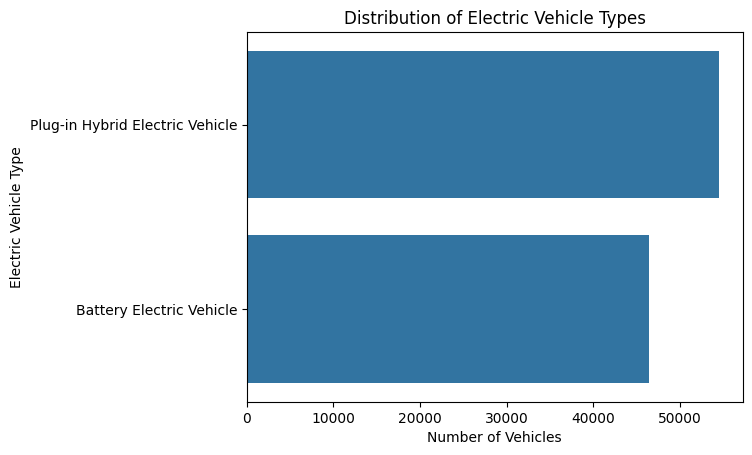

In [34]:
sns.countplot(
    data=df,
    y="Electric Vehicle Type",
    order=df["Electric Vehicle Type"].value_counts().index
)
plt.title("Distribution of Electric Vehicle Types")
plt.xlabel("Number of Vehicles")
plt.ylabel("Electric Vehicle Type")
plt.show()

### **2. Distribution of Model Year**
Analysis Type: Univariate<br>
Visualization Type: Line Chart
#### **Explanation**
This line chart shows a clear increase in electric vehicle counts over recent model years, indicating rapid growth in EV adoption.

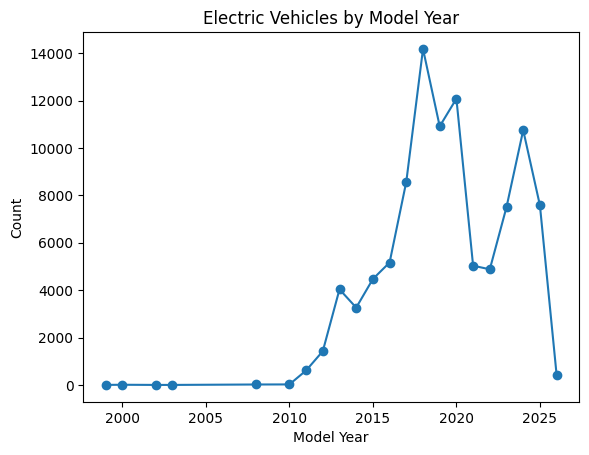

In [35]:
yearly = df["Model Year"].value_counts().sort_index()

plt.plot(yearly.index, yearly.values, marker="o")
plt.title("Electric Vehicles by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Count")
plt.show()

### **3. Distribution of Vehicle Age**
Analysis Type: Univariate<br>
Visualization Type: Histogram
#### **Explanation**
This histogram shows that most electric vehicles are relatively new, with higher counts in lower vehicle-age ranges and fewer older vehicles.

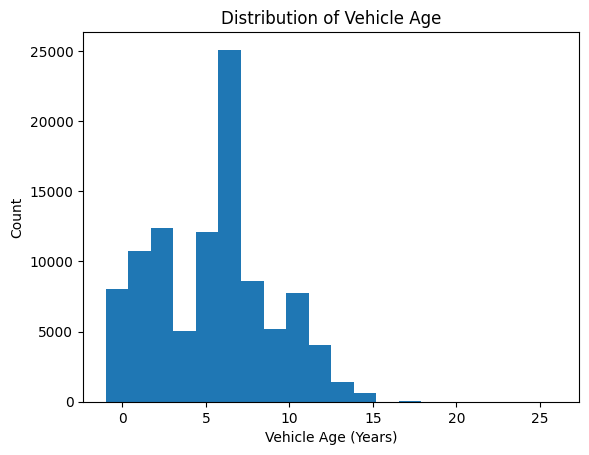

In [36]:
plt.hist(df["Vehicle Age"], bins=20)
plt.title("Distribution of Vehicle Age")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Count")
plt.show()

### **4. Distribution of Electric Range**
Analysis Type: Univariate<br>
Visualization Type: Histogram
#### **Explanation**
This histogram shows that most electric vehicles have lower to mid electric ranges, while fewer vehicles offer very high range values.

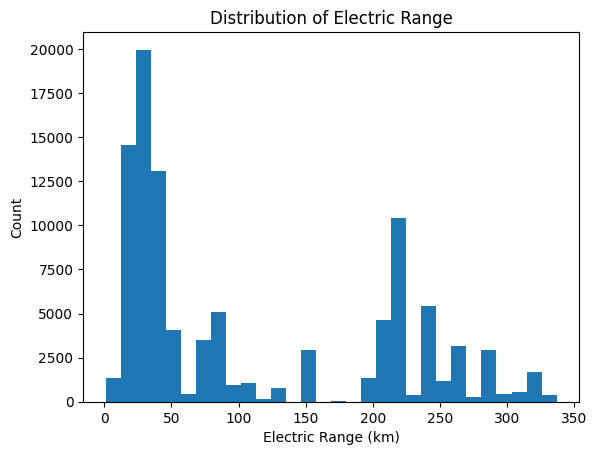

In [37]:
plt.hist(df["Electric Range"], bins=30)
plt.title("Distribution of Electric Range")
plt.xlabel("Electric Range (km)")
plt.ylabel("Count")
plt.show()

### **5. Electric Range by Vehicle Type**
Analysis Type: Bivariate<br>
Visualization Type: Box Plot
#### **Explanation**
This box plot shows that Battery Electric Vehicles have significantly higher and more varied electric ranges compared to Plug-in Hybrid Electric Vehicles.

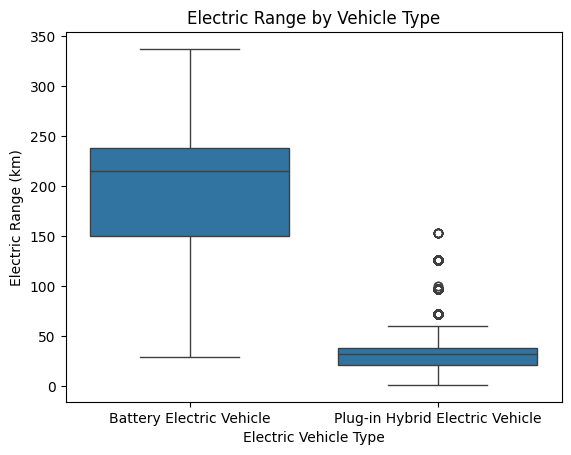

In [38]:
sns.boxplot(
    data=df,
    x="Electric Vehicle Type",
    y="Electric Range"
)
plt.title("Electric Range by Vehicle Type")
plt.xlabel("Electric Vehicle Type")
plt.ylabel("Electric Range (km)")
plt.show()

### **6. Top 10 Counties by EV Count**
Analysis Type: Bivariate<br>
Visualization Type: Bar Chart
#### **Explanation**
This bar chart shows that King County has the highest number of electric vehicles, followed by Snohomish and Pierce counties, indicating EV adoption is concentrated in a few major counties.

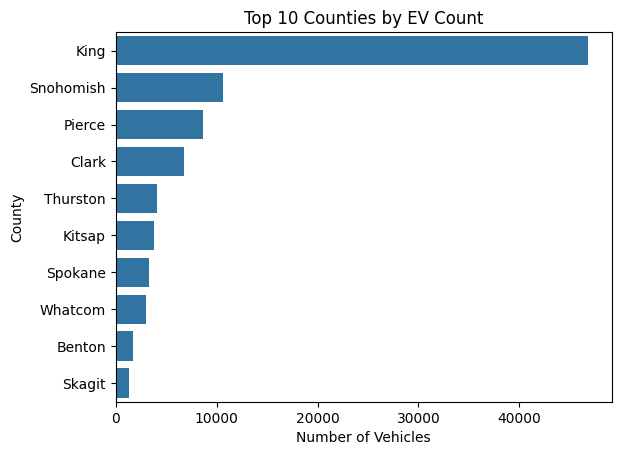

In [39]:
top_counties = df["County"].value_counts().head(10)

sns.barplot(x=top_counties.values, y=top_counties.index)
plt.title("Top 10 Counties by EV Count")
plt.xlabel("Number of Vehicles")
plt.ylabel("County")
plt.show()

### **7. CAFV Eligibility Distribution**
Analysis Type: Bivariate<br>
Visualization Type: Pie Chart
#### **Explanation**
This pie chart shows that most electric vehicles are CAFV eligible, while a smaller portion is not eligible.

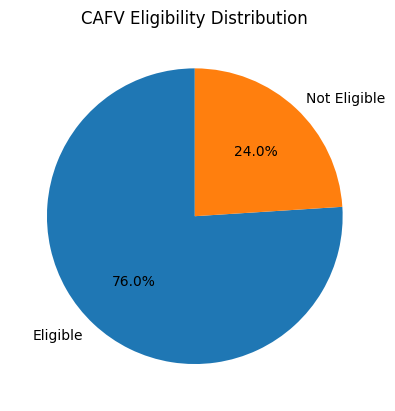

In [40]:
df["CAFV Eligibility"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("CAFV Eligibility Distribution")
plt.ylabel("")
plt.show()

### **8. Electric Range Category vs Vehicle Type**
Analysis Type: Bivariate<br>
Visualization Type: Grouped Bar Chart
#### **Explanation**
This chart shows that Battery Electric Vehicles dominate the high-range category, while Plug-in Hybrid Electric Vehicles are mostly concentrated in the low-range category.

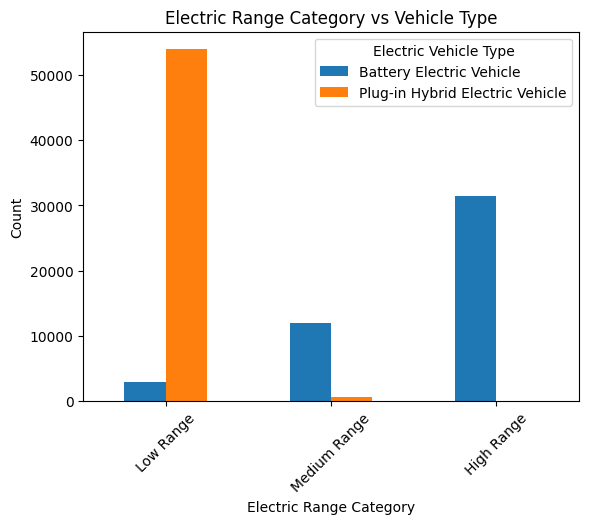

In [41]:
pivot = pd.crosstab(
    df["Electric Range Category"],
    df["Electric Vehicle Type"]
)

pivot.plot(kind="bar")
plt.title("Electric Range Category vs Vehicle Type")
plt.xlabel("Electric Range Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### **9. Vehicle Age vs Electric Range**
Analysis Type: Bivariate<br>
Visualization Type: Scatter Plot
#### **Explanation**
This scatter plot shows that newer vehicles generally have higher electric ranges, while older vehicles tend to have lower ranges, indicating improvements in EV technology over time.

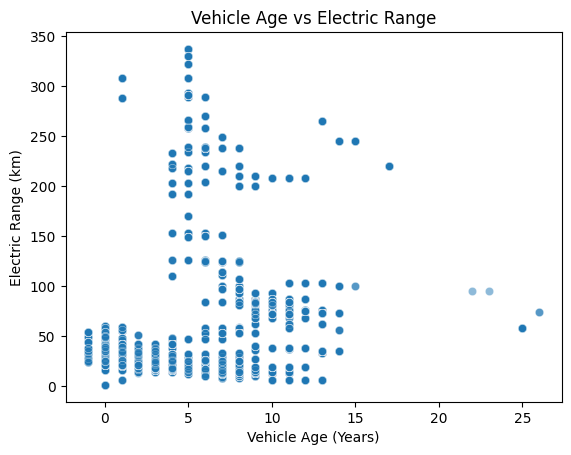

In [42]:
sns.scatterplot(
    data=df,
    x="Vehicle Age",
    y="Electric Range",
    alpha=0.5
)
plt.title("Vehicle Age vs Electric Range")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Electric Range (km)")
plt.show()

### **10. Average Electric Range by Vehicle Type**
Analysis Type: Bivariate<br>
Visualization Type: Bar Chart
#### **Explanation**
This bar chart shows that Battery Electric Vehicles have a much higher average electric range than Plug-in Hybrid Electric Vehicles.

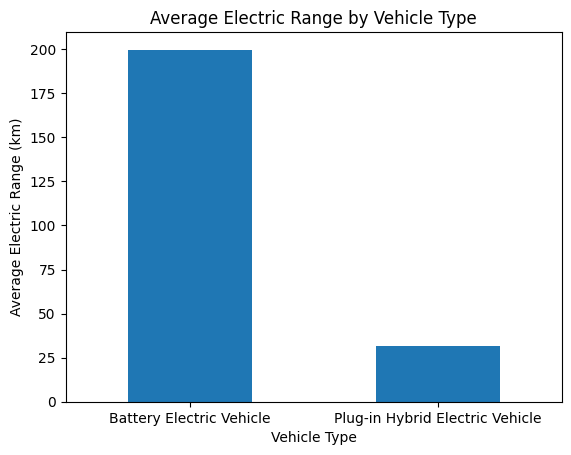

In [43]:
avg_range_type = df.groupby("Electric Vehicle Type")["Electric Range"].mean()

avg_range_type.plot(kind="bar")
plt.title("Average Electric Range by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Electric Range (km)")
plt.xticks(rotation=0)
plt.show()

### **11. Correlation Heatmap**
Analysis Type: Multivariate<br>
Visualization Type: Heatmap
#### **Explanation**
This heatmap shows a strong negative correlation between model year and vehicle age, and a weak positive relationship between vehicle age and electric range.

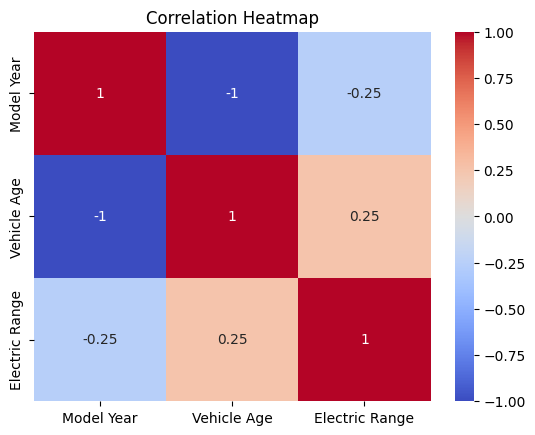

In [44]:
numeric_df = df[["Model Year", "Vehicle Age", "Electric Range"]]

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

### **12. EV Growth Trend by Vehicle Type**
Analysis Type: Multivariate<br>
Visualization Type: Line Chart
#### **Explanation**
This line chart shows that both Battery Electric Vehicles and Plug-in Hybrid Electric Vehicles increase over time.

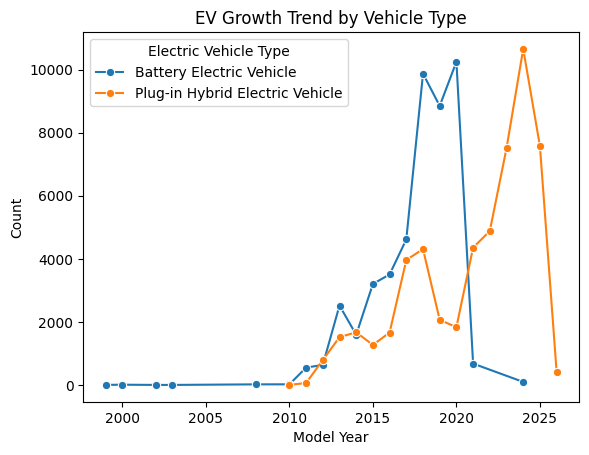

In [45]:
trend = df.groupby(
    ["Model Year", "Electric Vehicle Type"]
).size().reset_index(name="Count")

sns.lineplot(
    data=trend,
    x="Model Year",
    y="Count",
    hue="Electric Vehicle Type",
    marker="o"
)
plt.title("EV Growth Trend by Vehicle Type")
plt.xlabel("Model Year")
plt.ylabel("Count")
plt.show()

### **13. Average Electric Range by Model Year**
Analysis Type: Multivariate<br>
Visualization Type: Line Chart
#### **Explanation**
This line chart shows that the average electric range has generally increased over newer model years, reflecting improvements in EV battery technology.

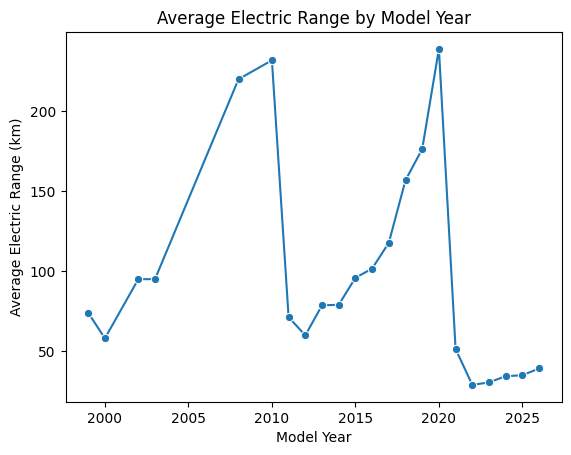

In [46]:
avg_range_year = (
    df.groupby("Model Year")["Electric Range"]
    .mean().reset_index(name="Avg Electric Range")
)

sns.lineplot(
    data=avg_range_year,
    x="Model Year",
    y="Avg Electric Range",
    marker="o"
)

plt.title("Average Electric Range by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Average Electric Range (km)")
plt.show()

## **Summary**
### **Major Insights from the Analysis**
#### **Insight 1: Steady Growth in Electric Vehicle Adoption**

The number of electric vehicles has increased consistently over recent model years.
This reflects rising adoption driven by technological advancements and environmental awareness.


#### **Insight 2: Technological Improvements Have Enhanced Electric Range**

Vehicles from recent model years generally exhibit higher electric range values.
This trend highlights progress in battery efficiency and vehicle design.

#### **Insight 3: Electric Range Differs Across Vehicle Categories**

Electric range varies noticeably between BEVs and PHEVs.
BEVs tend to offer longer range, while variability within each category suggests differences across manufacturers.

#### **Insight 4: Regional Differences in EV Adoption Are Evident**

Electric vehicle ownership is concentrated in certain states and counties.
This uneven distribution may be influenced by regional infrastructure and policy initiatives.

#### **Insight 5: Incentive Programs Encourage EV Adoption**

A large proportion of vehicles qualify for Clean Alternative Fuel Vehicle (CAFV) benefits.
This indicates that incentive programs play a significant role in promoting electric vehicle usage.

### **Conclusion**
1. Electric vehicle adoption has shown consistent growth over time.

2. Battery Electric Vehicles dominate the market share.

3. Newer vehicles generally provide higher electric range measured in kilometers.

4. EV adoption varies considerably across regions.

5. Incentives and supportive policies positively influence adoption rates.

6. Expanding charging infrastructure can further accelerate electric vehicle adoption.

7. Continued government support through incentive schemes can encourage sustainable transportation.

8. Manufacturers should focus on improving range efficiency and cost-effectiveness.

9. Consumers can leverage such analyses to make informed purchasing decisions.